## Partie 4 : Régression — Prédiction de `Prix_Revente`

> Variable cible : **`Prix_Revente`** | Split : **70 % Train | 15 % Val | 15 % Test** (stratifié sur `Categorie`)

In [34]:
target_reg = 'Prix_Revente'
X_reg      = df_clean.drop(['Categorie', 'Rapport_Collecte', target_reg], axis=1)
y_reg      = df_clean[target_reg].reset_index(drop=True)
cat_strat  = df_clean['Categorie'].reset_index(drop=True)

scaler_reg   = StandardScaler()
X_reg_scaled = pd.DataFrame(scaler_reg.fit_transform(X_reg), columns=X_reg.columns)

X_r_train, X_r_temp, y_r_train, y_r_temp, cat_train, cat_temp = train_test_split(
    X_reg_scaled, y_reg, cat_strat,
    test_size=0.30, random_state=42, stratify=cat_strat
)

X_r_val, X_r_test, y_r_val, y_r_test = train_test_split(
    X_r_temp, y_r_temp,
    test_size=0.50, random_state=42, stratify=cat_temp
)

print(f"Train Reg : {X_r_train.shape} | Val Reg : {X_r_val.shape} | Test Reg : {X_r_test.shape}")

def reg_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:<35} RMSE: {rmse:9.3f} | MAE: {mae:9.3f} | R2: {r2:.4f}")
    return rmse, mae, r2

Train Reg : (6734, 6) | Val Reg : (1443, 6) | Test Reg : (1443, 6)


### 4.1 — Régression Linéaire (OLS)

In [35]:
ols = LinearRegression()
ols.fit(X_r_train, y_r_train)
y_pred_ols = ols.predict(X_r_test)
ols_rmse, ols_mae, ols_r2 = reg_metrics("Régression Linéaire (OLS)", y_r_test, y_pred_ols)

Régression Linéaire (OLS)           RMSE:     2.481 | MAE:     1.923 | R2: 0.7563


### 4.2 — Ridge

In [36]:
best_alpha_ridge, best_r2_val = 0.1, -np.inf
for a in [0.01, 0.1, 1, 10, 100]:
    ridge_tmp = Ridge(alpha=a)
    ridge_tmp.fit(X_r_train, y_r_train)
    r2_v = r2_score(y_r_val, ridge_tmp.predict(X_r_val))
    if r2_v > best_r2_val:
        best_r2_val, best_alpha_ridge = r2_v, a

print(f"Meilleur alpha Ridge = {best_alpha_ridge}  |  Val R2 = {best_r2_val:.4f}")
ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_r_train, y_r_train)
y_pred_ridge = ridge.predict(X_r_test)
ridge_rmse, ridge_mae, ridge_r2 = reg_metrics("Ridge", y_r_test, y_pred_ridge)

Meilleur alpha Ridge = 0.01  |  Val R2 = 0.7535
Ridge                               RMSE:     2.481 | MAE:     1.923 | R2: 0.7563


### 4.3 — Lasso

In [37]:
best_alpha_lasso, best_r2_val = 0.001, -np.inf
for a in [0.0001, 0.001, 0.01, 0.1, 1]:
    lasso_tmp = Lasso(alpha=a, max_iter=5000)
    lasso_tmp.fit(X_r_train, y_r_train)
    r2_v = r2_score(y_r_val, lasso_tmp.predict(X_r_val))
    if r2_v > best_r2_val:
        best_r2_val, best_alpha_lasso = r2_v, a

print(f"Meilleur alpha Lasso = {best_alpha_lasso}  |  Val R2 = {best_r2_val:.4f}")
lasso = Lasso(alpha=best_alpha_lasso, max_iter=5000)
lasso.fit(X_r_train, y_r_train)
y_pred_lasso = lasso.predict(X_r_test)
lasso_rmse, lasso_mae, lasso_r2 = reg_metrics("Lasso", y_r_test, y_pred_lasso)

Meilleur alpha Lasso = 0.0001  |  Val R2 = 0.7535
Lasso                               RMSE:     2.481 | MAE:     1.923 | R2: 0.7563


### 4.4 — k-NN Régression

In [38]:
best_k_r, best_r2_val = 1, -np.inf
for k in range(1, 21):
    knnr_tmp = KNeighborsRegressor(n_neighbors=k)
    knnr_tmp.fit(X_r_train, y_r_train)
    r2_v = r2_score(y_r_val, knnr_tmp.predict(X_r_val))
    if r2_v > best_r2_val:
        best_r2_val, best_k_r = r2_v, k

print(f"Meilleur k (Régression) = {best_k_r}  |  Val R2 = {best_r2_val:.4f}")
knnr = KNeighborsRegressor(n_neighbors=best_k_r)
knnr.fit(X_r_train, y_r_train)
y_pred_knnr = knnr.predict(X_r_test)
knnr_rmse, knnr_mae, knnr_r2 = reg_metrics(f"kNN Regression (k={best_k_r})", y_r_test, y_pred_knnr)

Meilleur k (Régression) = 1  |  Val R2 = 0.9735
kNN Regression (k=1)                RMSE:     0.719 | MAE:     0.155 | R2: 0.9795


### 4.5 — Decision Tree Régression

In [39]:
best_depth_r, best_r2_val = None, -np.inf
for d in [None, 3, 5, 7, 10]:
    dtr_tmp = DecisionTreeRegressor(max_depth=d, random_state=42)
    dtr_tmp.fit(X_r_train, y_r_train)
    r2_v = r2_score(y_r_val, dtr_tmp.predict(X_r_val))
    if r2_v > best_r2_val:
        best_r2_val, best_depth_r = r2_v, d

print(f"Meilleur max_depth (Régression) = {best_depth_r}  |  Val R2 = {best_r2_val:.4f}")
dtr = DecisionTreeRegressor(max_depth=best_depth_r, random_state=42)
dtr.fit(X_r_train, y_r_train)
y_pred_dtr = dtr.predict(X_r_test)
dtr_rmse, dtr_mae, dtr_r2 = reg_metrics(f"Decision Tree Reg (depth={best_depth_r})", y_r_test, y_pred_dtr)

Meilleur max_depth (Régression) = 10  |  Val R2 = 0.9799
Decision Tree Reg (depth=10)        RMSE:     0.779 | MAE:     0.187 | R2: 0.9760


### 4.6 — Random Forest Régression

In [40]:
rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(X_r_train, y_r_train)
y_pred_rfr = rfr.predict(X_r_test)
rfr_rmse, rfr_mae, rfr_r2 = reg_metrics("Random Forest Regression", y_r_test, y_pred_rfr)

cv_rfr = cross_val_score(rfr, X_r_train, y_r_train, cv=5, scoring='r2')
print(f"CV R2 (5 folds) : {cv_rfr.round(3)} | Moyenne : {cv_rfr.mean():.3f} ± {cv_rfr.std():.3f}")

Random Forest Regression            RMSE:     0.716 | MAE:     0.161 | R2: 0.9797
CV R2 (5 folds) : [0.992 0.995 0.987 0.989 0.978] | Moyenne : 0.988 ± 0.006


### 4.7 — SVR (kernel RBF)

In [41]:
svr = SVR(kernel='rbf')
svr.fit(X_r_train, y_r_train)
y_pred_svr = svr.predict(X_r_test)
svr_rmse, svr_mae, svr_r2 = reg_metrics("SVR (RBF)", y_r_test, y_pred_svr)

SVR (RBF)                           RMSE:     1.195 | MAE:     0.453 | R2: 0.9435


### 4.8 — Gradient Boosting Régression

In [42]:
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr.fit(X_r_train, y_r_train)
y_pred_gbr = gbr.predict(X_r_test)
gbr_rmse, gbr_mae, gbr_r2 = reg_metrics("Gradient Boosting Regression", y_r_test, y_pred_gbr)

Gradient Boosting Regression        RMSE:     0.800 | MAE:     0.276 | R2: 0.9747


## Partie 5 : Tableau Comparatif — Régression

In [43]:
results_reg = pd.DataFrame([
    {'Algorithme': 'Régression Linéaire',        'RMSE': ols_rmse,   'MAE': ols_mae,   'R2': ols_r2},
    {'Algorithme': 'Ridge',                      'RMSE': ridge_rmse, 'MAE': ridge_mae, 'R2': ridge_r2},
    {'Algorithme': 'Lasso',                      'RMSE': lasso_rmse, 'MAE': lasso_mae, 'R2': lasso_r2},
    {'Algorithme': f'kNN Reg (k={best_k_r})',    'RMSE': knnr_rmse,  'MAE': knnr_mae,  'R2': knnr_r2},
    {'Algorithme': 'Decision Tree Reg',          'RMSE': dtr_rmse,   'MAE': dtr_mae,   'R2': dtr_r2},
    {'Algorithme': 'Random Forest Reg',          'RMSE': rfr_rmse,   'MAE': rfr_mae,   'R2': rfr_r2},
    {'Algorithme': 'SVR (RBF)',                  'RMSE': svr_rmse,   'MAE': svr_mae,   'R2': svr_r2},
    {'Algorithme': 'Gradient Boosting',          'RMSE': gbr_rmse,   'MAE': gbr_mae,   'R2': gbr_r2},
]).set_index('Algorithme').round(4).sort_values('R2', ascending=False)

print("Classement des modèles de Régression (ensemble Test) :")
display(results_reg.style.background_gradient(cmap='YlGn', subset=['R2'])
                         .background_gradient(cmap='YlOrRd_r', subset=['RMSE', 'MAE']))

Classement des modèles de Régression (ensemble Test) :


,RMSE,MAE,R2
Algorithme,,,
Random Forest Reg,0.716100,0.160900,0.979700
kNN Reg (k=1),0.718900,0.155200,0.979500
Decision Tree Reg,0.778800,0.187200,0.976000
Gradient Boosting,0.799900,0.276100,0.974700
SVR (RBF),1.195000,0.453200,0.943500
Lasso,2.480700,1.923200,0.756300
Régression Linéaire,2.480700,1.923200,0.756300
Ridge,2.480700,1.923200,0.756300


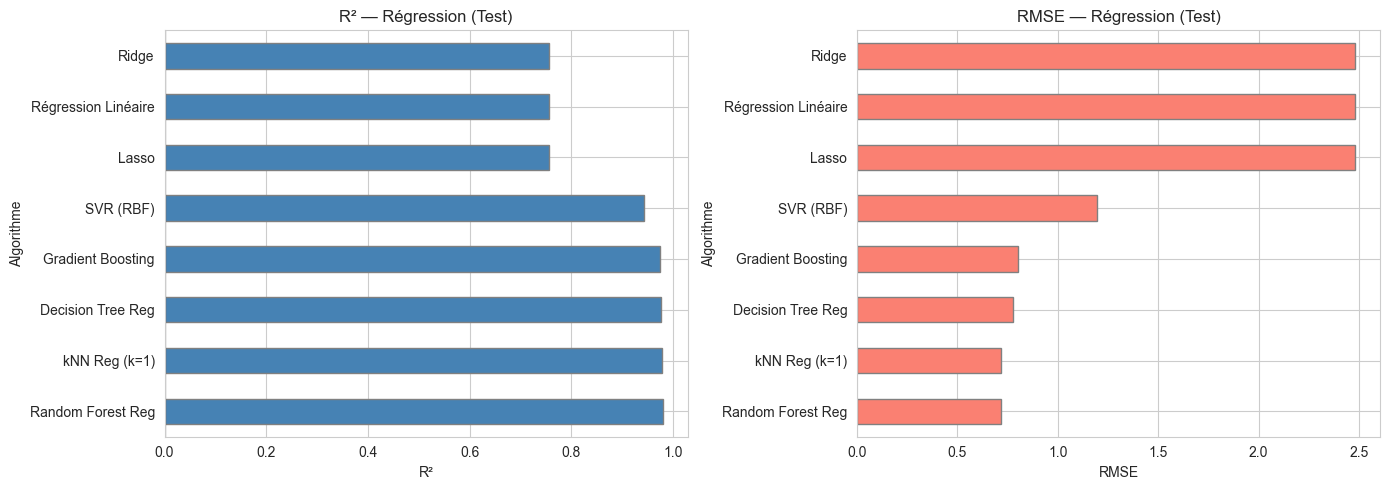

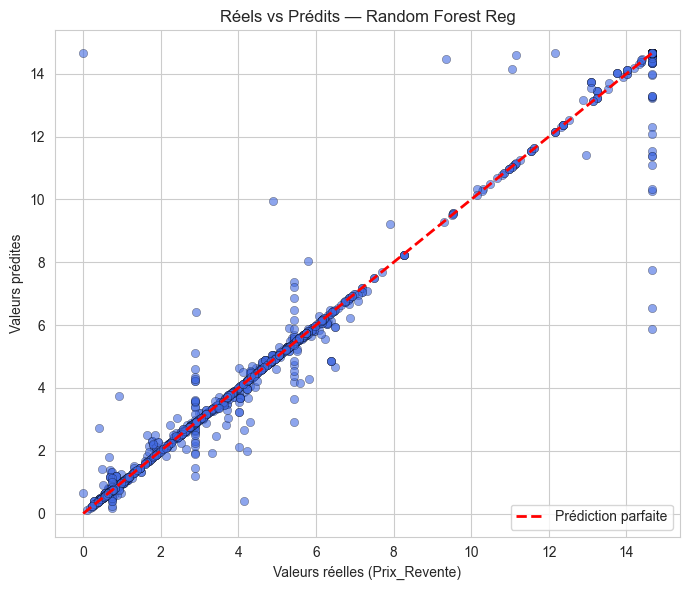

Meilleur modèle : Random Forest Reg  |  R² = 0.9797


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_reg['R2'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='grey')
axes[0].set_title('R² — Régression (Test)', fontsize=12)
axes[0].set_xlabel('R²')
axes[0].axvline(0, color='black', linewidth=0.8)

results_reg['RMSE'].plot(kind='barh', ax=axes[1], color='salmon', edgecolor='grey')
axes[1].set_title('RMSE — Régression (Test)', fontsize=12)
axes[1].set_xlabel('RMSE')

plt.tight_layout()
plt.show()

# Réels vs prédits — meilleur modèle
best_reg_name = results_reg['R2'].idxmax()
best_preds_map = {
    'Régression Linéaire'       : y_pred_ols,
    'Ridge'                     : y_pred_ridge,
    'Lasso'                     : y_pred_lasso,
    f'kNN Reg (k={best_k_r})'   : y_pred_knnr,
    'Decision Tree Reg'         : y_pred_dtr,
    'Random Forest Reg'         : y_pred_rfr,
    'SVR (RBF)'                 : y_pred_svr,
    'Gradient Boosting'         : y_pred_gbr,
}
best_y_pred = best_preds_map[best_reg_name]

plt.figure(figsize=(7, 6))
plt.scatter(y_r_test, best_y_pred, alpha=0.6, edgecolors='k', linewidths=0.3, color='royalblue')
lims = [min(y_r_test.min(), best_y_pred.min()), max(y_r_test.max(), best_y_pred.max())]
plt.plot(lims, lims, 'r--', lw=2, label='Prédiction parfaite')
plt.xlabel('Valeurs réelles (Prix_Revente)')
plt.ylabel('Valeurs prédites')
plt.title(f'Réels vs Prédits — {best_reg_name}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Meilleur modèle : {best_reg_name}  |  R² = {results_reg.loc[best_reg_name, 'R2']:.4f}")

---
# 🔬 MODULE 3 : Sélection de Features (SHAP) & Tuning Avancé

> **Objectifs :**  
> 1. Expliquer les prédictions via les **SHAP values** (SHapley Additive exPlanations)  
> 2. Comparer **GridSearchCV** et **Optuna** pour le tuning d'hyperparamètres

## 3.1 — Sélection de Features par SHAP Values

SHAP non disponible — affichage de la feature importance sklearn.


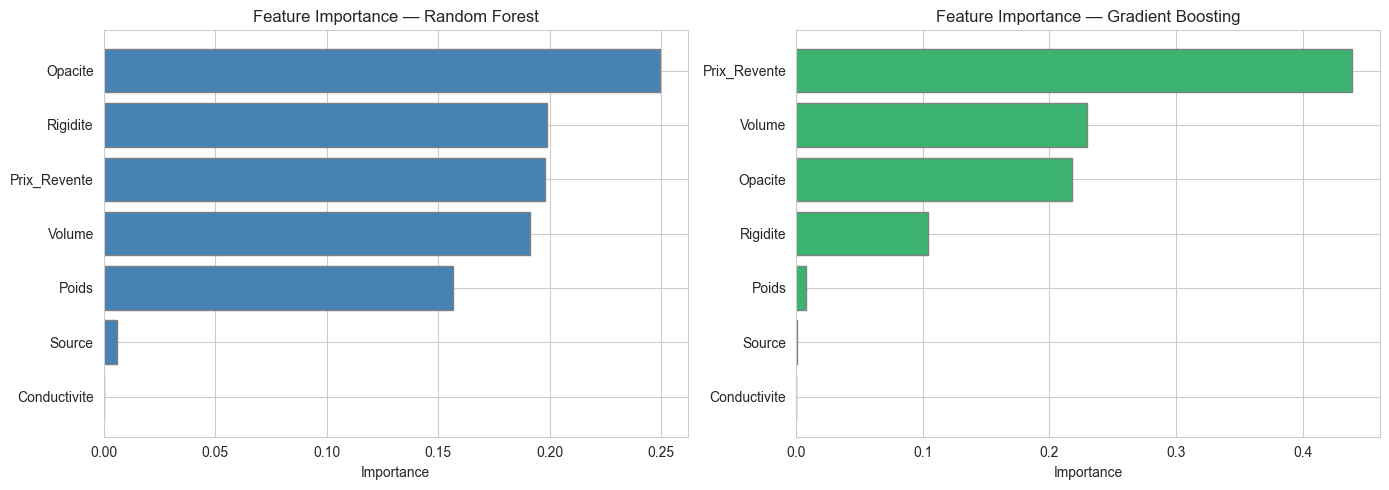


💡 Astuce : pip install shap  pour les graphiques SHAP complets.


In [45]:
if SHAP_AVAILABLE:
    # Utiliser le modèle GBC entraîné précédemment
    explainer  = shap.TreeExplainer(gbc)
    shap_values = explainer.shap_values(X_test)

    print("Type de shap_values :", type(shap_values))

    # ── Summary Plot (importance globale) ────────────────────────────────────
    plt.figure()
    shap.summary_plot(
        shap_values if isinstance(shap_values, np.ndarray) else shap_values[0],
        X_test,
        plot_type='bar',
        show=True
    )

    # ── Summary Plot (beeswarm) ───────────────────────────────────────────────
    plt.figure()
    shap.summary_plot(
        shap_values if isinstance(shap_values, np.ndarray) else shap_values[0],
        X_test,
        show=True
    )
else:
    # ── Fallback : Feature Importance intégrée (sklearn) ─────────────────────
    print("SHAP non disponible — affichage de la feature importance sklearn.")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, model, name, color in [
        (axes[0], model_rf,  'Random Forest',     'steelblue'),
        (axes[1], gbc,       'Gradient Boosting', 'mediumseagreen')
    ]:
        imp_df = pd.DataFrame({
            'Feature'   : X.columns,
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=True)

        ax.barh(imp_df['Feature'], imp_df['Importance'], color=color, edgecolor='grey')
        ax.set_title(f'Feature Importance — {name}')
        ax.set_xlabel('Importance')

    plt.tight_layout()
    plt.show()
    print("\n💡 Astuce : pip install shap  pour les graphiques SHAP complets.")

### 3.1.b — Sélection des K meilleures features (via SHAP ou permutation)

In [46]:
if SHAP_AVAILABLE:
    sv = shap_values if isinstance(shap_values, np.ndarray) else shap_values[0]
    mean_shap = np.abs(sv).mean(axis=0)
    feature_importance_shap = pd.Series(mean_shap, index=X.columns).sort_values(ascending=False)
else:
    feature_importance_shap = pd.Series(
        gbc.feature_importances_, index=X.columns
    ).sort_values(ascending=False)

print("Importance des features (SHAP / sklearn) :")
print(feature_importance_shap.round(4))

# Sélectionner les TOP-K features
K_FEATURES = 4
top_features = feature_importance_shap.head(K_FEATURES).index.tolist()
print(f"\n✅ Top-{K_FEATURES} features sélectionnées : {top_features}")

X_train_top = X_train[top_features]
X_val_top   = X_val[top_features]
X_test_top  = X_test[top_features]

# Évaluation rapide avec les features réduites
gbc_top = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbc_top.fit(X_train_top, y_train)
top_acc = accuracy_score(y_test, gbc_top.predict(X_test_top))
top_f1  = f1_score(y_test, gbc_top.predict(X_test_top), average='weighted', zero_division=0)

print(f"\nGBC (toutes features)  → F1 = {gbc_f1:.3f} | Accuracy = {gbc_acc:.3f}")
print(f"GBC (top-{K_FEATURES} features) → F1 = {top_f1:.3f} | Accuracy = {top_acc:.3f}")

Importance des features (SHAP / sklearn) :
Prix_Revente    0.4391
Volume          0.2296
Opacite         0.2182
Rigidite        0.1045
Poids           0.0082
Source          0.0004
Conductivite    0.0000
dtype: float64

✅ Top-4 features sélectionnées : ['Prix_Revente', 'Volume', 'Opacite', 'Rigidite']

GBC (toutes features)  → F1 = 0.943 | Accuracy = 0.956
GBC (top-4 features) → F1 = 0.935 | Accuracy = 0.953


## 3.2 — Tuning par GridSearchCV

> Recherche exhaustive sur une grille de paramètres prédéfinie avec validation croisée stratifiée.

In [47]:
print("=" * 60)
print("  GRIDSEACHCV — Gradient Boosting Classifier")
print("=" * 60)

param_grid_gbc = {
    'n_estimators' : [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth'    : [2, 3, 5],
    'subsample'    : [0.8, 1.0]
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gbc,
    cv=cv_strat,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Meilleurs paramètres : {grid_search.best_params_}")
print(f"   CV F1 (val) = {grid_search.best_score_:.4f}")

best_gbc_grid = grid_search.best_estimator_
y_pred_grid   = best_gbc_grid.predict(X_test)
grid_f1       = f1_score(y_test, y_pred_grid, average='weighted', zero_division=0)
grid_acc      = accuracy_score(y_test, y_pred_grid)

print(f"   Test F1       = {grid_f1:.4f}")
print(f"   Test Accuracy = {grid_acc:.4f}")

  GRIDSEACHCV — Gradient Boosting Classifier
Fitting 5 folds for each of 54 candidates, totalling 270 fits

✅ Meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
   CV F1 (val) = 0.9394
   Test F1       = 0.9415
   Test Accuracy = 0.9550


Top 10 combinaisons (GridSearchCV) :


,params,mean_test_score,std_test_score,rank_test_score
0,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",0.939425,0.003985,1
1,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.939385,0.003874,2
2,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",0.938937,0.004144,3
3,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",0.938799,0.003981,4
4,"{'learning_rate': 0.2, 'max_depth': 5, 'n_esti...",0.938798,0.003465,5
5,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.938541,0.004533,6
6,"{'learning_rate': 0.2, 'max_depth': 2, 'n_esti...",0.938480,0.002665,7
7,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.938205,0.003844,8
8,"{'learning_rate': 0.2, 'max_depth': 3, 'n_esti...",0.938190,0.001872,9
9,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",0.938168,0.004154,10


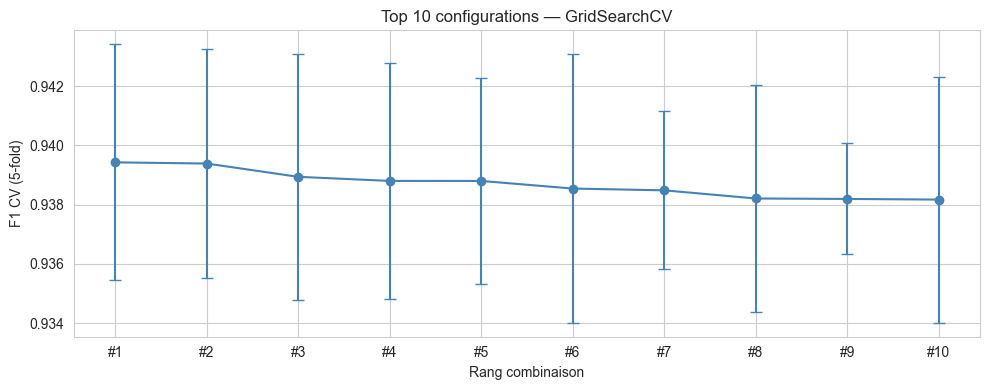

In [48]:
# Visualisation des résultats GridSearch
cv_results = pd.DataFrame(grid_search.cv_results_)
top10 = cv_results.nlargest(10, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]

print("Top 10 combinaisons (GridSearchCV) :")
display(top10.reset_index(drop=True))

plt.figure(figsize=(10, 4))
plt.errorbar(
    range(len(top10)),
    top10['mean_test_score'],
    yerr=top10['std_test_score'],
    fmt='o-', color='steelblue', capsize=4
)
plt.xticks(range(len(top10)), [f"#{i+1}" for i in range(len(top10))])
plt.xlabel('Rang combinaison')
plt.ylabel('F1 CV (5-fold)')
plt.title('Top 10 configurations — GridSearchCV')
plt.tight_layout()
plt.show()

## 3.3 — Tuning par Optuna (Bayesian Optimization)

> Optuna explore l'espace des hyperparamètres de manière **intelligente** (TPE sampler) — beaucoup plus efficace que la grille exhaustive pour les grands espaces.

In [49]:
if OPTUNA_AVAILABLE:
    def objective(trial):
        params = {
            'n_estimators' : trial.suggest_int('n_estimators',  50, 300),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth'    : trial.suggest_int('max_depth', 2, 6),
            'subsample'    : trial.suggest_float('subsample', 0.6, 1.0),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'max_features' : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        }
        clf = GradientBoostingClassifier(**params, random_state=42)
        cv_scores = cross_val_score(
            clf, X_train, y_train,
            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            scoring='f1_weighted',
            n_jobs=-1
        )
        return cv_scores.mean()

    study = optuna.create_study(direction='maximize', study_name='GBC_Optuna')
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    print(f"\n✅ Meilleur trial Optuna : {study.best_trial.number}")
    print(f"   Best CV F1 = {study.best_value:.4f}")
    print(f"   Best params: {study.best_params}")

    # Modèle final Optuna
    best_gbc_optuna = GradientBoostingClassifier(**study.best_params, random_state=42)
    best_gbc_optuna.fit(X_train, y_train)
    y_pred_optuna = best_gbc_optuna.predict(X_test)
    optuna_f1  = f1_score(y_test, y_pred_optuna, average='weighted', zero_division=0)
    optuna_acc = accuracy_score(y_test, y_pred_optuna)

    print(f"   Test F1       = {optuna_f1:.4f}")
    print(f"   Test Accuracy = {optuna_acc:.4f}")

    # Courbe d'optimisation
    trials_df = study.trials_dataframe()
    plt.figure(figsize=(10, 4))
    plt.plot(trials_df['number'], trials_df['value'], alpha=0.5, label='Trial F1')
    plt.plot(trials_df['number'], trials_df['value'].cummax(),
             color='red', linewidth=2, label='Meilleur F1 cumulé')
    plt.xlabel('Numéro du trial')
    plt.ylabel('F1 (CV)')
    plt.title('Optimisation Optuna — Convergence')
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("⚠️  Optuna non installé. Tuning Optuna ignoré.")
    print("   → pip install optuna")
    optuna_f1  = None
    optuna_acc = None

⚠️  Optuna non installé. Tuning Optuna ignoré.
   → pip install optuna


## 3.4 — Comparaison Finale : Baseline vs GridSearch vs Optuna

Comparaison Baseline / GridSearch / Optuna :


,F1-Test,Accuracy
Modèle,,
GBC Baseline,0.942500,0.956300
GBC + GridSearchCV,0.941500,0.955000


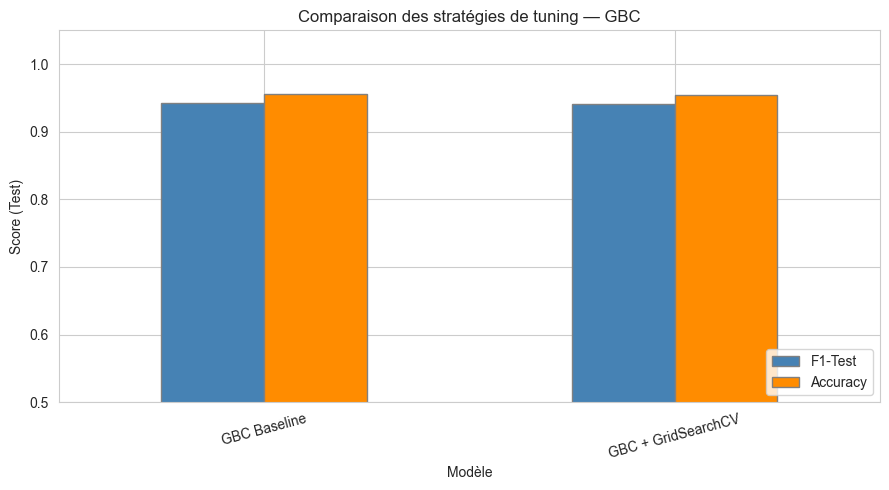

In [50]:
comparison_rows = [
    {'Modèle': 'GBC Baseline',       'F1-Test': gbc_f1,    'Accuracy': gbc_acc},
    {'Modèle': 'GBC + GridSearchCV', 'F1-Test': grid_f1,   'Accuracy': grid_acc},
]

if optuna_f1 is not None:
    comparison_rows.append(
        {'Modèle': 'GBC + Optuna', 'F1-Test': optuna_f1, 'Accuracy': optuna_acc}
    )

comparison_df = pd.DataFrame(comparison_rows).set_index('Modèle').round(4)
print("Comparaison Baseline / GridSearch / Optuna :")
display(comparison_df.style.highlight_max(axis=0, color='lightgreen'))

# Visualisation
comparison_df.plot(kind='bar', figsize=(9, 5), color=['steelblue', 'darkorange'], edgecolor='grey')
plt.title('Comparaison des stratégies de tuning — GBC')
plt.xticks(rotation=15)
plt.ylabel('Score (Test)')
plt.ylim(0.5, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()